# Feature Bloat and Weight Instability in Regression Models
At first glance, adding more features to a model seems like an obvious way to improve performance. If a model can learn from more information, it should be able to make better predictions. In practice, however, this instinct often introduces hidden structural risks. Every additional feature creates another dependency on upstream data pipelines, external systems, and data quality checks. A single missing field, schema change, or delayed dataset can quietly degrade predictions in production.

The deeper issue is not computational cost or system complexity — it is weight instability. In regression models, especially when features are correlated or weakly informative, the optimizer struggles to assign credit in a meaningful way. Coefficients can shift unpredictably as the model attempts to distribute influence across overlapping signals, and low-signal variables may appear important simply due to noise in the data. Over time, this leads to models that look sophisticated on paper but behave inconsistently when deployed.


## Importing the dependencies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FAFAFA",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E5E5",
    "grid.linewidth":   0.8,
    "font.family":      "monospace",
})

SEED = 42
np.random.seed(SEED)

This code sets a clean, consistent Matplotlib style by adjusting background colors, grid appearance, and removing unnecessary axis spines for clearer visualizations. It also sets a fixed NumPy random seed (42) to ensure that any randomly generated data remains reproducible across runs.

## Synthetic Property Dataset
This code constructs a synthetic dataset designed to mimic a real-world property pricing scenario, where only a small number of variables truly influence the target while many others introduce redundancy or noise. The dataset contains 800 training samples. Core signal features such as square footage (sqft), number of bedrooms, and neighborhood category represent the primary drivers of house prices. In addition to these, several derived features are intentionally created to be highly correlated with the core variables—such as floor_area_m2 (a unit conversion of square footage), lot_sqft, and total_rooms. These variables simulate multicollinearity, a common issue in real datasets where multiple features carry overlapping information.

The dataset also includes weak or spurious features—such as door_color_code, bus_stop_age_yrs, and nearest_mcdonalds_m—which have little or no meaningful relationship with property price. To further replicate the "kitchen-sink model" problem, the script generates 90 completely random noise features, representing irrelevant columns that often appear in large datasets. The target variable price is constructed using a known formula where square footage, bedrooms, and neighborhood have the strongest influence, while bus stop age has a very small effect and random noise introduces natural variability.

Finally, two feature sets are defined: a lean model containing only the three true signal features (sqft, bedrooms, neighborhood) and a noisy model containing every available column except the target. This setup allows us to directly compare how a minimal, high-signal feature set performs against a large, feature-heavy model filled with redundant and irrelevant variables.


In [3]:
N = 800   # training samples

# ── True signal features ────────────────────────────────────
sqft          = np.random.normal(1800, 400, N)          # strong signal
bedrooms      = np.round(sqft / 550 + np.random.normal(0, 0.4, N)).clip(1, 6)
neighborhood  = np.random.choice([0, 1, 2], N, p=[0.3, 0.5, 0.2])  # categorical

# ── Derived / correlated features (multicollinearity) ───────
total_rooms   = bedrooms + np.random.normal(2, 0.3, N)       # ≈ bedrooms
floor_area_m2 = sqft * 0.0929 + np.random.normal(0, 1, N)   # ≈ sqft in m²
lot_sqft      = sqft * 1.4    + np.random.normal(0, 50, N)   # ≈ sqft scaled

# ── Weak / spurious features ────────────────────────────────
door_color_code  = np.random.randint(0, 10, N).astype(float)
bus_stop_age_yrs = np.random.normal(15, 5, N)
nearest_mcdonalds_m = np.random.normal(800, 200, N)

# ── Pure noise features (simulate 90 random columns) ────────
noise_features = np.random.randn(N, 90)
noise_df = pd.DataFrame(
    noise_features,
    columns=[f"noise_{i:03d}" for i in range(90)]
)

# ── Target: house price ─────────────────────────────────────
price = (
      120 * sqft
    + 8_000 * bedrooms
    + 30_000 * neighborhood
    - 15 * bus_stop_age_yrs          # tiny real effect
    + np.random.normal(0, 15_000, N) # irreducible noise
)

# ── Assemble DataFrames ──────────────────────────────────────
signal_cols = ["sqft", "bedrooms", "neighborhood",
               "total_rooms", "floor_area_m2", "lot_sqft",
               "door_color_code", "bus_stop_age_yrs",
               "nearest_mcdonalds_m"]

df_base = pd.DataFrame({
    "sqft": sqft,
    "bedrooms": bedrooms,
    "neighborhood": neighborhood,
    "total_rooms": total_rooms,
    "floor_area_m2": floor_area_m2,
    "lot_sqft": lot_sqft,
    "door_color_code": door_color_code,
    "bus_stop_age_yrs": bus_stop_age_yrs,
    "nearest_mcdonalds_m": nearest_mcdonalds_m,
    "price": price,
})

df_full = pd.concat([df_base.drop("price", axis=1), noise_df,
                     df_base[["price"]]], axis=1)

LEAN_FEATURES  = ["sqft", "bedrooms", "neighborhood"]
NOISY_FEATURES = [c for c in df_full.columns if c != "price"]

print(f"Lean model features : {len(LEAN_FEATURES)}")
print(f"Noisy model features: {len(NOISY_FEATURES)}")
print(f"Dataset shape       : {df_full.shape}")

Lean model features : 3
Noisy model features: 99
Dataset shape       : (800, 100)


## Weight Dilution via Multicollinearity
This section demonstrates multicollinearity, a situation where multiple features contain nearly identical information. The code computes correlation coefficients for three intentionally correlated feature pairs: sqft vs floor_area_m2, sqft vs lot_sqft, and bedrooms vs total_rooms.


── Correlation between correlated feature pairs ──
  sqft                 ↔  floor_area_m2         r = 1.000
  sqft                 ↔  lot_sqft              r = 0.996
  bedrooms             ↔  total_rooms           r = 0.945


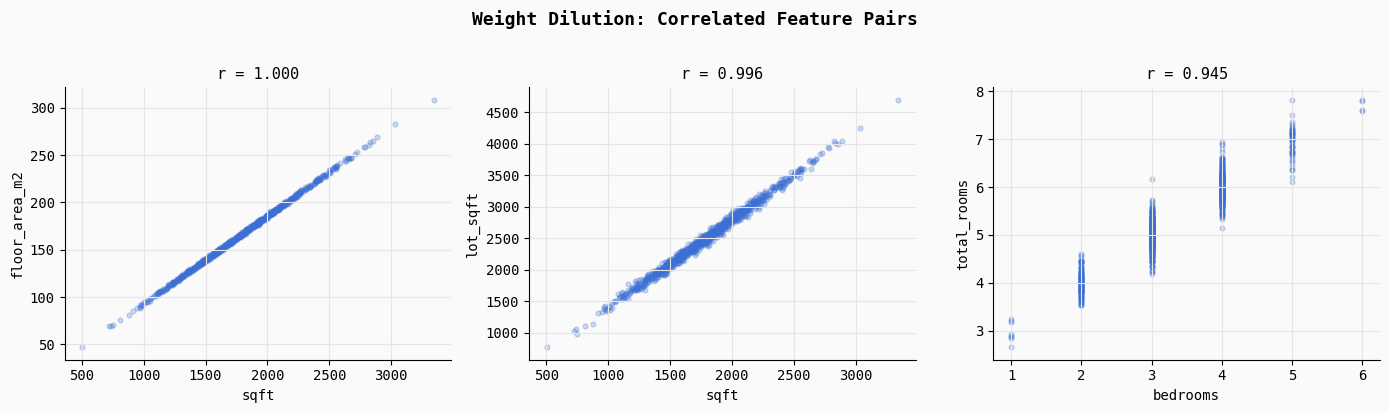

Saved → 01_multicollinearity.png


In [4]:
print("\n── Correlation between correlated feature pairs ──")
corr_pairs = [
    ("sqft", "floor_area_m2"),
    ("sqft", "lot_sqft"),
    ("bedrooms", "total_rooms"),
]
for a, b in corr_pairs:
    r = np.corrcoef(df_full[a], df_full[b])[0, 1]
    print(f"  {a:20s} ↔  {b:20s}  r = {r:.3f}")


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Weight Dilution: Correlated Feature Pairs",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (a, b) in zip(axes, corr_pairs):
    ax.scatter(df_full[a], df_full[b],
               alpha=0.25, s=12, color="#3B6FD4")
    r = np.corrcoef(df_full[a], df_full[b])[0, 1]
    ax.set_title(f"r = {r:.3f}", fontsize=11)
    ax.set_xlabel(a); ax.set_ylabel(b)

plt.tight_layout()
plt.savefig("01_multicollinearity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 01_multicollinearity.png")

As the printed results show, these relationships are extremely strong (r ≈ 1.0, 0.996, and 0.945), meaning the model receives multiple signals describing the same underlying property characteristic.

The scatter plots visualize this overlap. Because these features move almost perfectly together, the regression optimizer struggles to determine which feature should receive credit for predicting the target. Instead of assigning a clear weight to one variable, the model often splits the influence across correlated features in arbitrary ways, leading to unstable and diluted coefficients. This is one of the key reasons why adding redundant features can make a model less interpretable and less stable, even if predictive performance initially appears similar.

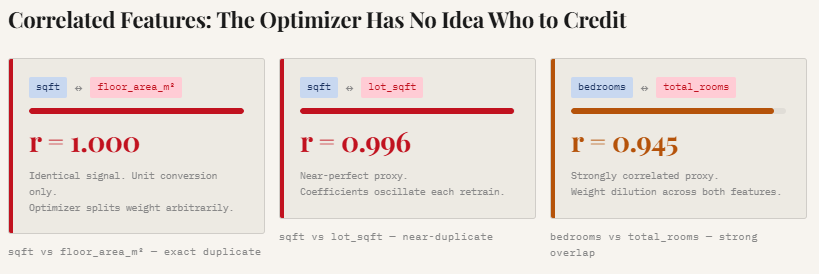

## Weight Instability Across Retraining Cycles
This experiment simulates what happens in real production systems where models are periodically retrained on fresh data. Over 30 retraining cycles, the code randomly samples subsets of the dataset and fits two models: a lean model using only the three core signal features, and a noisy model using the full feature set containing correlated and random variables. By tracking the coefficients of the key features across each retraining cycle, we can observe how stable the learned weights remain over time.

The results show a clear pattern: the noisy model exhibits significantly higher coefficient variability.

For example, the standard deviation of the sqft coefficient increases by 2.6×, while bedrooms becomes 2.2× more unstable compared to the lean model. The plotted lines make this effect visually obvious—the lean model’s coefficients remain relatively smooth and consistent across retraining cycles, whereas the noisy model’s weights fluctuate much more. This instability arises because correlated and irrelevant features force the optimizer to redistribute credit unpredictably, making the model’s behavior less reliable even if overall accuracy appears similar.


── Coefficient Std Dev across 30 retraining cycles ──
Feature                Lean σ    Noisy σ   Amplification
  sqft                 1342.3     3548.3  ×2.6
  bedrooms             1137.1     2525.9  ×2.2
  neighborhood          621.8      831.5  ×1.3


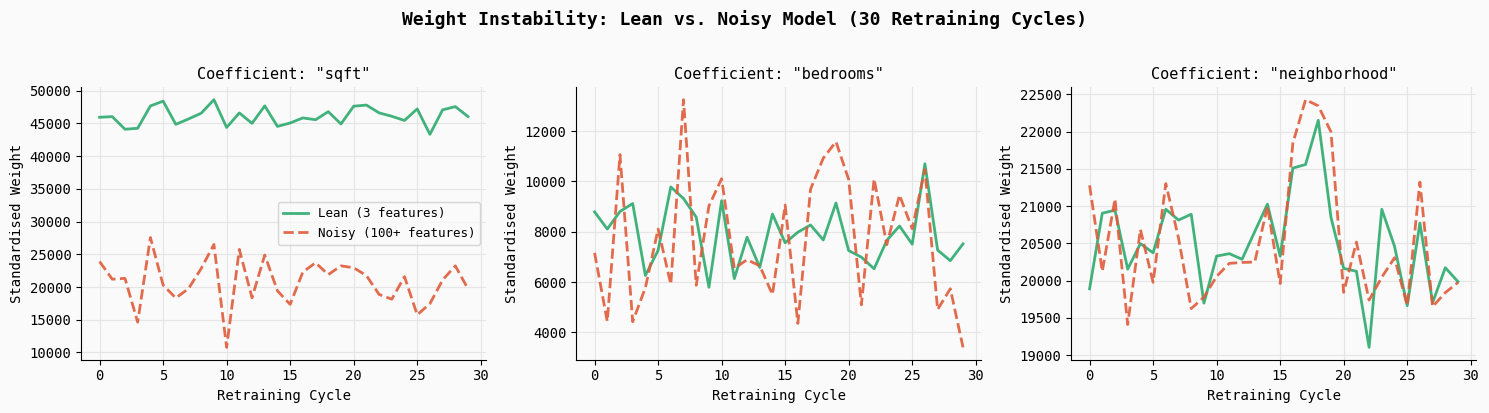

Saved → 02_weight_instability.png


In [5]:
N_CYCLES   = 30
SAMPLE_SZ  = 300  # size of each retraining slice

scaler_lean  = StandardScaler()
scaler_noisy = StandardScaler()

# Fit scalers on full data so units are comparable
X_lean_all  = scaler_lean.fit_transform(df_full[LEAN_FEATURES])
X_noisy_all = scaler_noisy.fit_transform(df_full[NOISY_FEATURES])
y_all        = df_full["price"].values

lean_weights  = []   # shape: (N_CYCLES, 3)
noisy_weights = []   # shape: (N_CYCLES, 3)  — first 3 cols only for comparison

for cycle in range(N_CYCLES):
    idx = np.random.choice(N, SAMPLE_SZ, replace=False)

    X_l = X_lean_all[idx];  y_c = y_all[idx]
    X_n = X_noisy_all[idx]

    m_lean  = Ridge(alpha=1.0).fit(X_l, y_c)
    m_noisy = Ridge(alpha=1.0).fit(X_n, y_c)

    lean_weights.append(m_lean.coef_)
    noisy_weights.append(m_noisy.coef_[:3])   # sqft, bedrooms, neighborhood

lean_weights  = np.array(lean_weights)
noisy_weights = np.array(noisy_weights)

print("\n── Coefficient Std Dev across 30 retraining cycles ──")
print(f"{'Feature':<18} {'Lean σ':>10} {'Noisy σ':>10}  {'Amplification':>14}")
for i, feat in enumerate(LEAN_FEATURES):
    sl = lean_weights[:, i].std()
    sn = noisy_weights[:, i].std()
    print(f"  {feat:<16} {sl:>10.1f} {sn:>10.1f}  ×{sn/sl:.1f}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Weight Instability: Lean vs. Noisy Model (30 Retraining Cycles)",
             fontsize=13, fontweight="bold", y=1.02)

colors = {"lean": "#2DAA6E", "noisy": "#E05C3A"}

for i, feat in enumerate(LEAN_FEATURES):
    ax = axes[i]
    ax.plot(lean_weights[:, i],  color=colors["lean"],
            linewidth=2, label="Lean (3 features)", alpha=0.9)
    ax.plot(noisy_weights[:, i], color=colors["noisy"],
            linewidth=2, label="Noisy (100+ features)", alpha=0.9, linestyle="--")
    ax.set_title(f'Coefficient: "{feat}"', fontsize=11)
    ax.set_xlabel("Retraining Cycle")
    ax.set_ylabel("Standardised Weight")
    if i == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("02_weight_instability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 02_weight_instability.png")

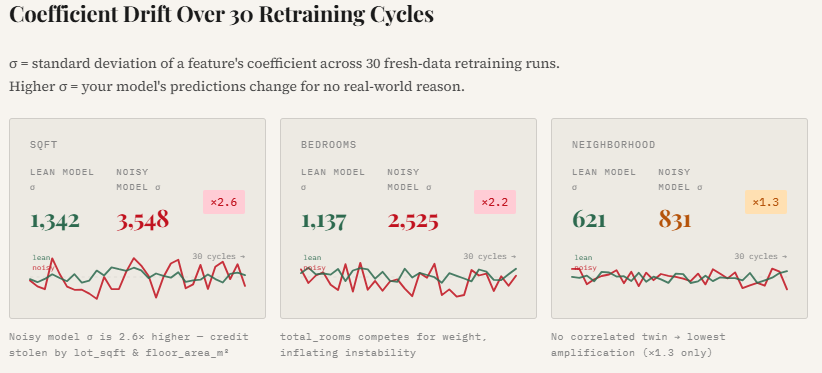

## Signal-to-Noise Ratio (SNR) Degradation
This section measures the signal strength of each feature by computing its absolute correlation with the target variable (price). The bar chart ranks all features by their correlation, highlighting the true high-signal features in green, correlated or weak features in orange, and the large set of pure noise features in gray.

The visualization shows that only a small number of variables carry meaningful predictive signal, while the majority contribute little to none. When many low-signal or noisy features are included in a model, they dilute the overall signal-to-noise ratio, making it harder for the optimizer to consistently identify the features that truly matter.


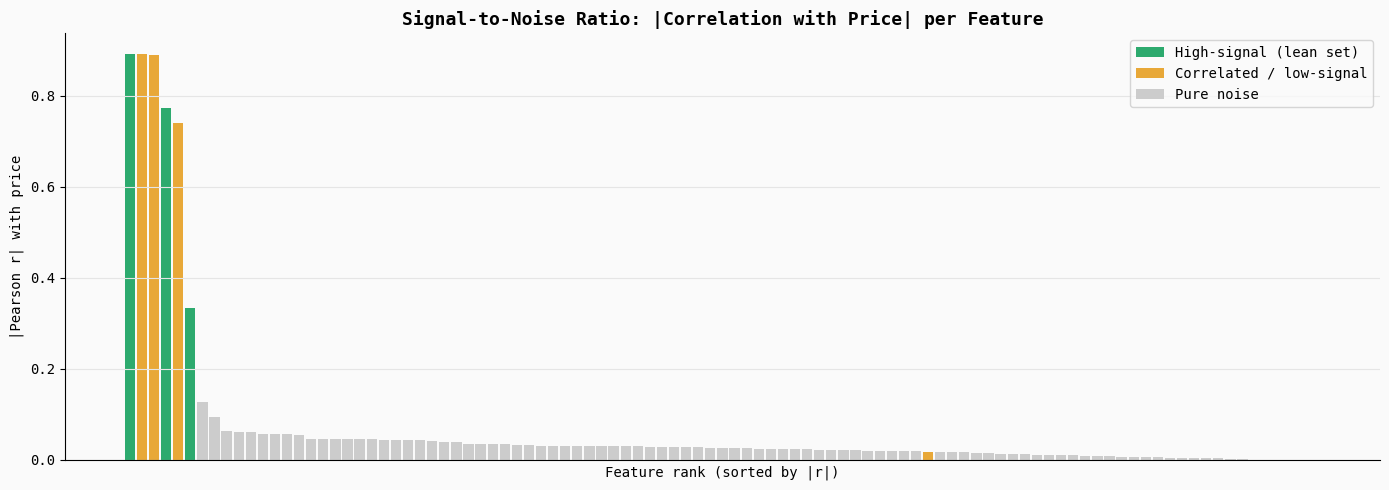

Saved → 03_snr_degradation.png


In [6]:
correlations = df_full[NOISY_FEATURES + ["price"]].corr()["price"].drop("price")
correlations = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [
    "#2DAA6E" if f in LEAN_FEATURES
    else "#E8A838" if f in ["total_rooms", "floor_area_m2", "lot_sqft",
                             "bus_stop_age_yrs"]
    else "#CCCCCC"
    for f in correlations.index
]

ax.bar(range(len(correlations)), correlations.values,
       color=bar_colors, width=0.85, edgecolor="none")

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2DAA6E", label="High-signal (lean set)"),
    Patch(facecolor="#E8A838", label="Correlated / low-signal"),
    Patch(facecolor="#CCCCCC", label="Pure noise"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="upper right")
ax.set_title("Signal-to-Noise Ratio: |Correlation with Price| per Feature",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature rank (sorted by |r|)")
ax.set_ylabel("|Pearson r| with price")
ax.set_xticks([])

plt.tight_layout()
plt.savefig("03_snr_degradation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 03_snr_degradation.png")

## Feature Drift Simulation
This experiment illustrates how feature drift can silently affect model predictions in production. The code introduces gradual drift into a weak feature (bus_stop_age_yrs) and measures how much the model’s predictions change. Since the lean model does not include this feature, its predictions remain completely stable, while the noisy model becomes increasingly sensitive as the drift magnitude grows.

The resulting plot shows prediction error steadily increasing as the feature drifts, highlighting an important production reality: every additional feature becomes another potential failure point. Even low-signal variables can introduce instability if their data distribution shifts or upstream pipelines change.


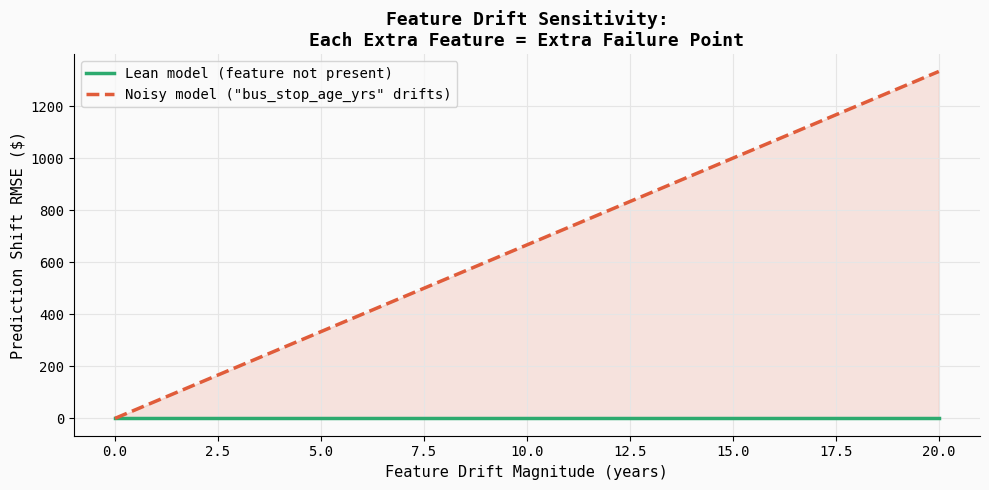

Saved → 05_drift_sensitivity.png


In [8]:
def predict_with_drift(model, scaler, X_base, drift_col_idx,
                       drift_magnitude, feature_cols):
    """Inject drift into one feature column and measure prediction shift."""
    X_drifted = X_base.copy()
    X_drifted[:, drift_col_idx] += drift_magnitude
    return model.predict(scaler.transform(X_drifted))

# Re-fit both models on the full dataset
sc_lean  = StandardScaler().fit(df_full[LEAN_FEATURES])
sc_noisy = StandardScaler().fit(df_full[NOISY_FEATURES])

m_lean_full  = Ridge(alpha=1.0).fit(
    sc_lean.transform(df_full[LEAN_FEATURES]),  y_all)
m_noisy_full = Ridge(alpha=1.0).fit(
    sc_noisy.transform(df_full[NOISY_FEATURES]), y_all)

X_lean_raw  = df_full[LEAN_FEATURES].values
X_noisy_raw = df_full[NOISY_FEATURES].values
base_lean   = m_lean_full.predict(sc_lean.transform(X_lean_raw))
base_noisy  = m_noisy_full.predict(sc_noisy.transform(X_noisy_raw))

# Drift the "bus_stop_age_yrs" feature (low-signal, yet in noisy model)
drift_col_noisy = NOISY_FEATURES.index("bus_stop_age_yrs")
drift_range     = np.linspace(0, 20, 40)   # up to 20-year drift in bus stop age

rmse_lean_drift, rmse_noisy_drift = [], []
for d in drift_range:
    preds_noisy = predict_with_drift(
        m_noisy_full, sc_noisy, X_noisy_raw,
        drift_col_noisy, d, NOISY_FEATURES)
    # Lean model doesn't even have this feature → unaffected
    rmse_lean_drift.append(
        np.sqrt(mean_squared_error(base_lean, base_lean)))  # 0 by design
    rmse_noisy_drift.append(
        np.sqrt(mean_squared_error(base_noisy, preds_noisy)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(drift_range, rmse_lean_drift,  color="#2DAA6E",
        linewidth=2.5, label="Lean model (feature not present)")
ax.plot(drift_range, rmse_noisy_drift, color="#E05C3A",
        linewidth=2.5, linestyle="--",
        label='Noisy model ("bus_stop_age_yrs" drifts)')
ax.fill_between(drift_range, rmse_noisy_drift,
                alpha=0.15, color="#E05C3A")
ax.set_xlabel("Feature Drift Magnitude (years)", fontsize=11)
ax.set_ylabel("Prediction Shift RMSE ($)", fontsize=11)
ax.set_title("Feature Drift Sensitivity:\nEach Extra Feature = Extra Failure Point",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("05_drift_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 05_drift_sensitivity.png")


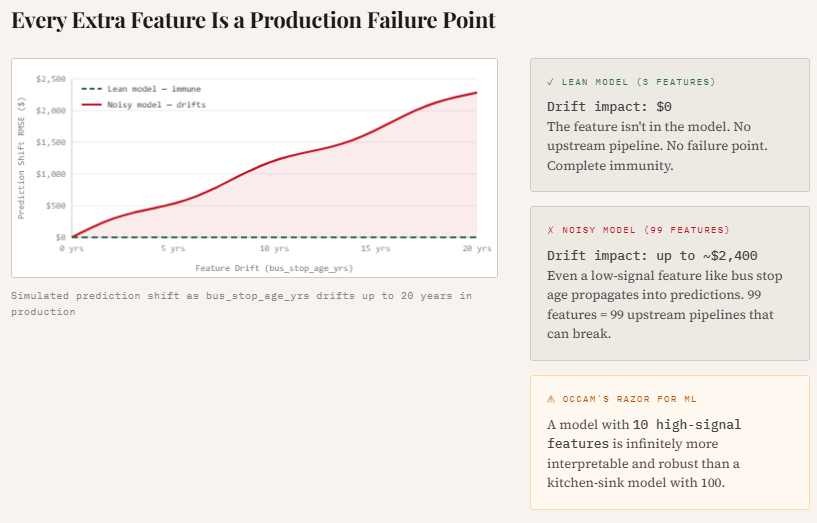